# CarAdvisor — Car Price Prediction & Recommendation System

**Author :** Dhruvik Parmar  
**Dataset :** Cars Datasets 2025

| Step | Description                            |
|------|----------------------------------------|
| 1    | Import Libraries                       |
| 2    | Load Dataset                           |
| 3    | Data Cleaning                          |
| 4    | Exploratory Data Analysis              |
| 5    | Correlation Heatmap                    |
| 6    | Feature vs Price Regression Plots      |
| 7    | Prepare Data for ML                    |
| 8    | Train Models + 5-Fold Cross-Validation |
| 9    | Model Comparison Charts                |
| 10   | Feature Importance                     |
| 11   | Car Recommendation System              |

In [1]:
# 1 - Import Libraries

import os
import re
import warnings
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree            import DecisionTreeRegressor
from sklearn.ensemble        import RandomForestRegressor
from sklearn.neighbors       import KNeighborsRegressor
from sklearn.svm             import SVR

print('All libraries imported successfully')

All libraries imported successfully


In [2]:
# 2 - Load Dataset

DATASET_PATH = os.path.join(os.getcwd(), 'Cars Datasets 2025.csv')

df = pd.read_csv(DATASET_PATH, encoding='latin1')
df.columns = df.columns.str.strip()

print('First 5 Rows')
display(df.head())

print('\nDataset Info')
print(df.info())

print('\nStatistical Summary')
display(df.describe(include='all'))

First 5 Rows


,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FERRARI,SF90 STRADALE,V8,3990 cc,963 hp,340 km/h,2.5 sec,"$1,100,000",plug in hyrbrid,2,800 Nm
1,ROLLS ROYCE,PHANTOM,V12,6749 cc,563 hp,250 km/h,5.3 sec,"$460,000",Petrol,5,900 Nm
2,Ford,KA+,1.2L Petrol,"1,200 cc",70-85 hp,165 km/h,10.5 sec,"$12,000-$15,000",Petrol,5,100 - 140 Nm
3,MERCEDES,GT 63 S,V8,"3,982 cc",630 hp,250 km/h,3.2 sec,"$161,000",Petrol,4,900 Nm
4,AUDI,AUDI R8 Gt,V10,"5,204 cc",602 hp,320 km/h,3.6 sec,"$253,290",Petrol,2,560 Nm



Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Company Names              1218 non-null   object
 1   Cars Names                 1218 non-null   object
 2   Engines                    1218 non-null   object
 3   CC/Battery Capacity        1215 non-null   object
 4   HorsePower                 1218 non-null   object
 5   Total Speed                1218 non-null   object
 6   Performance(0 - 100 )KM/H  1212 non-null   object
 7   Cars Prices                1218 non-null   object
 8   Fuel Types                 1218 non-null   object
 9   Seats                      1218 non-null   object
 10  Torque                     1217 non-null   object
dtypes: object(11)
memory usage: 104.8+ KB
None

Statistical Summary


,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
count,1218,1218,1218,1215,1218,1218,1212,1218,1218,1218,1217
unique,37,1201,356,311,456,114,180,535,23,19,263
top,Nissan,Polo BlueMotion,I4,1984 cc,355 hp,250 km/h,6.5 sec,"$35,000",Petrol,5,400 Nm
freq,149,2,64,31,23,145,45,36,871,692,72


In [3]:
# 3 - Data Cleaning

def clean_data(value):
    """Strips $ and commas, averages ranges like '200-300', returns np.nan if no number found."""
    value   = str(value).replace(',', '').replace('$', '')
    numbers = re.findall(r'\d+\.?\d*', value)
    if   len(numbers) == 2: return (float(numbers[0]) + float(numbers[1])) / 2
    elif len(numbers) == 1: return float(numbers[0])
    else:                   return np.nan


wanted_cols = ['CC/Battery Capacity', 'HorsePower', 'Total Speed',
               'Performance(0 - 100 )KM/H', 'Cars Prices', 'Seats', 'Torque']
columns_to_clean = [c for c in wanted_cols if c in df.columns]

for col in columns_to_clean:
    df[col] = df[col].apply(clean_data)

# Standardize text columns
df['Company Names'] = df['Company Names'].str.upper().str.strip()
df['Fuel Types']    = df['Fuel Types'].str.upper().str.strip()

# Drop rows with missing values
before = len(df)
df.dropna(inplace=True)
print(f'Rows removed : {before - len(df)}')

# Keep a clean copy for the recommendation system
df_original = df.copy()

# Log-transform price to reduce right skew
df['Log Price'] = np.log1p(df['Cars Prices'])

print(f'Total rows       : {df.shape[0]}')
print(f'Unique companies : {df["Company Names"].nunique()}')
print(f'Average price    : ${df["Cars Prices"].mean():>12,.2f}')
print(f'Max price        : ${df["Cars Prices"].max():>12,.2f}')
print(f'Min price        : ${df["Cars Prices"].min():>12,.2f}')

Rows removed : 21
Total rows       : 1197
Unique companies : 31
Average price    : $  139,401.81
Max price        : $18,000,000.00
Min price        : $    4,000.00


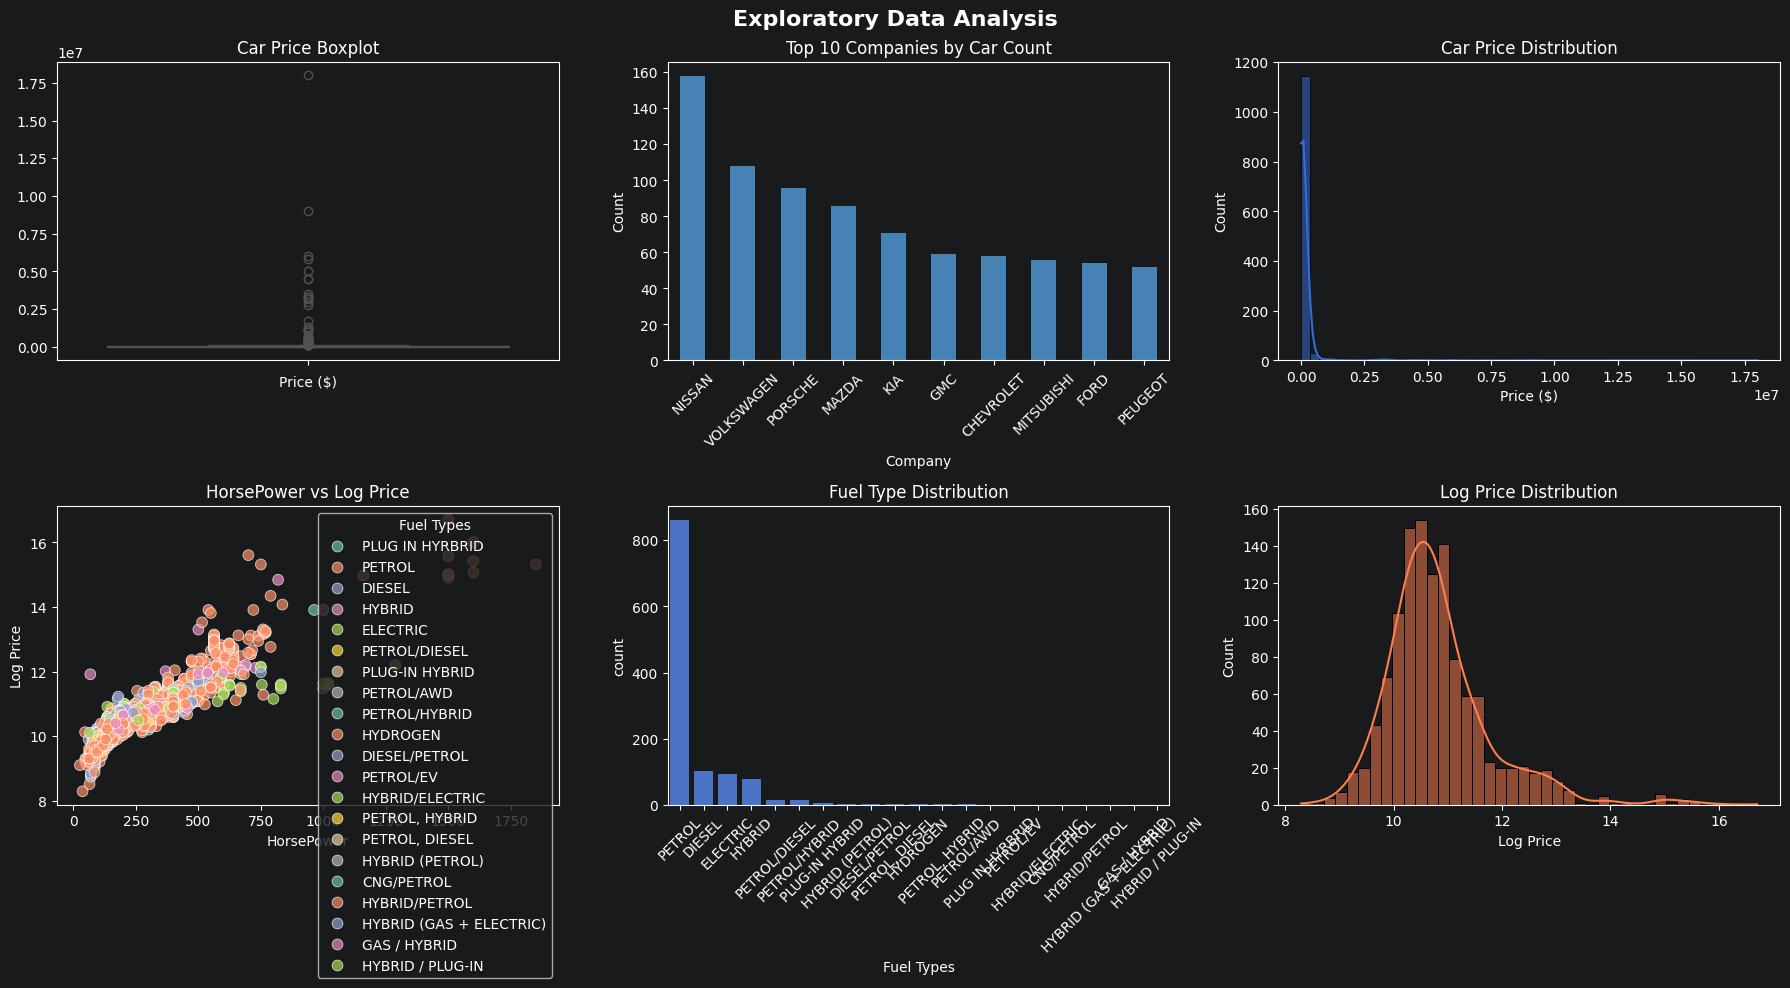

In [4]:
# 4 - Exploratory Data Analysis

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Exploratory Data Analysis', fontsize=16, fontweight='bold')

# Car Price Boxplot
sns.boxplot(data=df, y='Cars Prices', orient='h', ax=axes[0, 0])
axes[0, 0].set_title('Car Price Boxplot')
axes[0, 0].set_xlabel('Price ($)')
axes[0, 0].set_ylabel('')

# Top 10 Companies by Car Count
top_companies = df['Company Names'].value_counts().head(10)
top_companies.plot(kind='bar', ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Top 10 Companies by Car Count')
axes[0, 1].set_xlabel('Company')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)

# Car Price Distribution
sns.histplot(df['Cars Prices'], bins=50, kde=True, ax=axes[0, 2])
axes[0, 2].set_title('Car Price Distribution')
axes[0, 2].set_xlabel('Price ($)')

# HorsePower vs Log Price by Fuel Type
sns.scatterplot(data=df, x='HorsePower', y='Log Price',
                hue='Fuel Types', palette='Set2', s=60, alpha=0.7, ax=axes[1, 0])
axes[1, 0].set_title('HorsePower vs Log Price')

# Fuel Type Distribution
fuel_order = df['Fuel Types'].value_counts().index.tolist()
sns.countplot(data=df, x='Fuel Types', order=fuel_order, ax=axes[1, 1])
axes[1, 1].set_title('Fuel Type Distribution')
axes[1, 1].tick_params(axis='x', rotation=45)

# Log Price Distribution
sns.histplot(df['Log Price'], bins=40, kde=True, ax=axes[1, 2], color='coral')
axes[1, 2].set_title('Log Price Distribution')

plt.tight_layout()
plt.show()

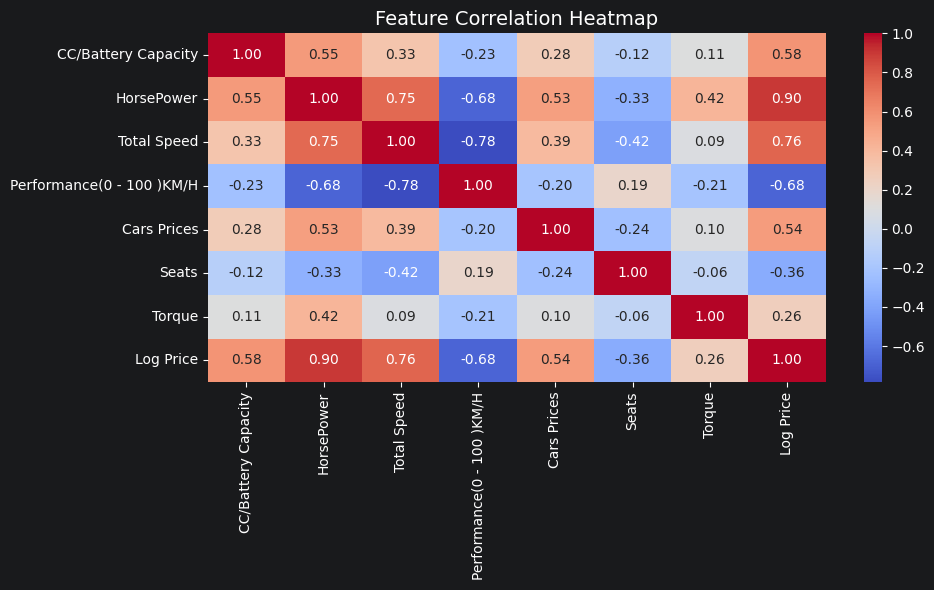

In [5]:
# 5 - Correlation Heatmap

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

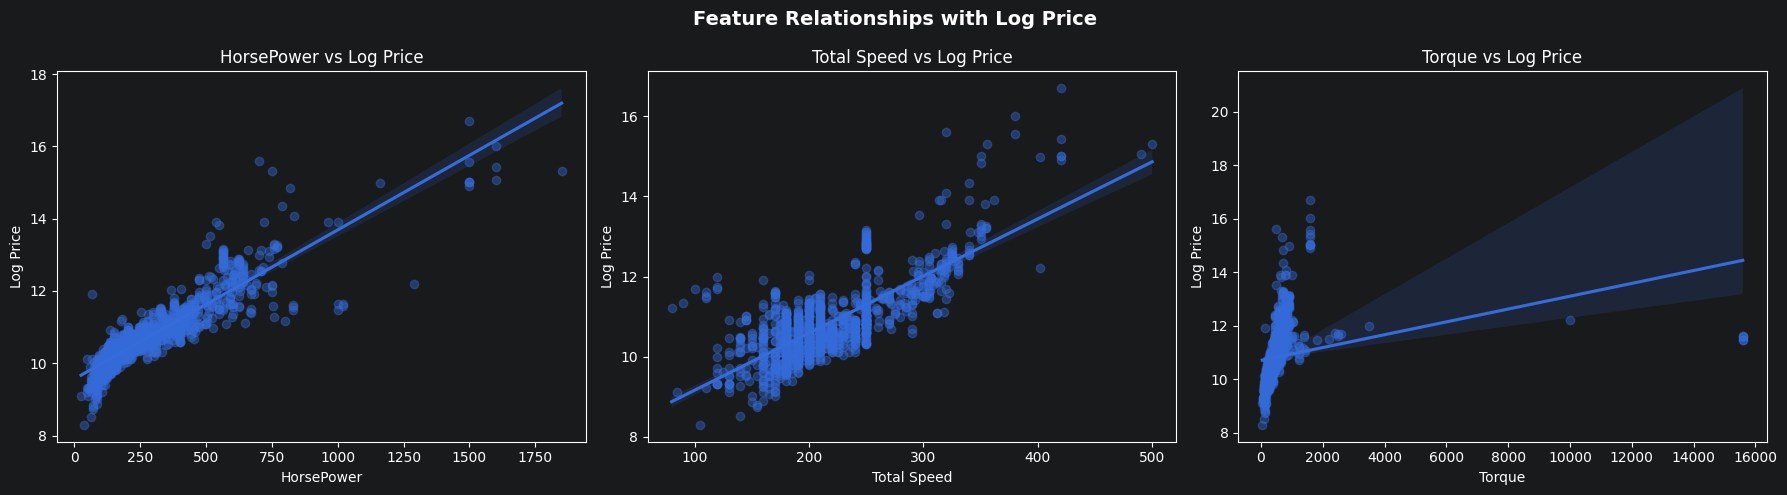

In [6]:
# 6 - Feature vs Log Price Regression Plots

candidate_features = ['HorsePower', 'Total Speed', 'Torque']
important_features = [f for f in candidate_features if f in df.columns]

fig, axes = plt.subplots(1, len(important_features), figsize=(6 * len(important_features), 5))
if len(important_features) == 1:
    axes = [axes]

fig.suptitle('Feature Relationships with Log Price', fontsize=14, fontweight='bold')

for ax, feature in zip(axes, important_features):
    sns.regplot(x=df[feature].values, y=df['Log Price'].values,
                ax=ax, scatter_kws={'alpha': 0.4})
    ax.set_title(f'{feature} vs Log Price')
    ax.set_xlabel(feature)
    ax.set_ylabel('Log Price')

plt.tight_layout()
plt.show()

In [7]:
# 7 - Prepare Data for Machine Learning

drop_cols = ['Cars Names', 'Engines', 'Fuel Types', 'Cars Prices']
df_model  = df.drop(columns=drop_cols, errors='ignore')

# One-hot encode company names
df_model = pd.get_dummies(df_model, columns=['Company Names'])

# Convert bool columns to int for sklearn compatibility
bool_cols = df_model.select_dtypes(include='bool').columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

X = df_model.drop('Log Price', axis=1)
y = df_model['Log Price']

# Train / Test split (80 / 20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')
print(f'Features         : {X_train.shape[1]}')

Training samples : 957
Testing  samples : 240
Features         : 37


In [8]:
# 8 - Train Models + Cross-Validation

model_definitions = {
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'KNN'          : KNeighborsRegressor(n_neighbors=5),
    'SVM'          : SVR(kernel='rbf', C=10, gamma='scale'),
}

kf      = KFold(n_splits=5, shuffle=True, random_state=42)
results = {}
trained = {}

for model_name, estimator in model_definitions.items():

    pipe = Pipeline([('scaler', StandardScaler()), ('model', estimator)])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    # 5-Fold Cross-Validation
    cv_scores = cross_val_score(pipe, X, y, cv=kf, scoring='r2')

    results[model_name] = {
        'MAE'        : round(mae,              4),
        'RMSE'       : round(rmse,             4),
        'R2'         : round(r2,               4),
        'CV R2 Mean' : round(cv_scores.mean(), 4),
        'CV R2 Std'  : round(cv_scores.std(),  4),
    }
    trained[model_name] = pipe

results_df = pd.DataFrame(results).T

print('Model Performance (with Cross-Validation)')
display(results_df)

best_model_name = results_df['CV R2 Mean'].idxmax()
best_cv_score   = results_df['CV R2 Mean'].max()
print(f'Best Model : {best_model_name}')
print(f'CV R2 Mean : {best_cv_score:.3f}')

Model Performance (with Cross-Validation)


,MAE,RMSE,R2,CV R2 Mean,CV R2 Std
Decision Tree,0.1902,0.3058,0.8956,0.8595,0.0568
Random Forest,0.1600,0.2513,0.9295,0.9200,0.0165
KNN,0.2163,0.3109,0.8921,0.8753,0.0310
SVM,0.1605,0.2422,0.9345,0.9121,0.0169


Best Model : Random Forest
CV R2 Mean : 0.920


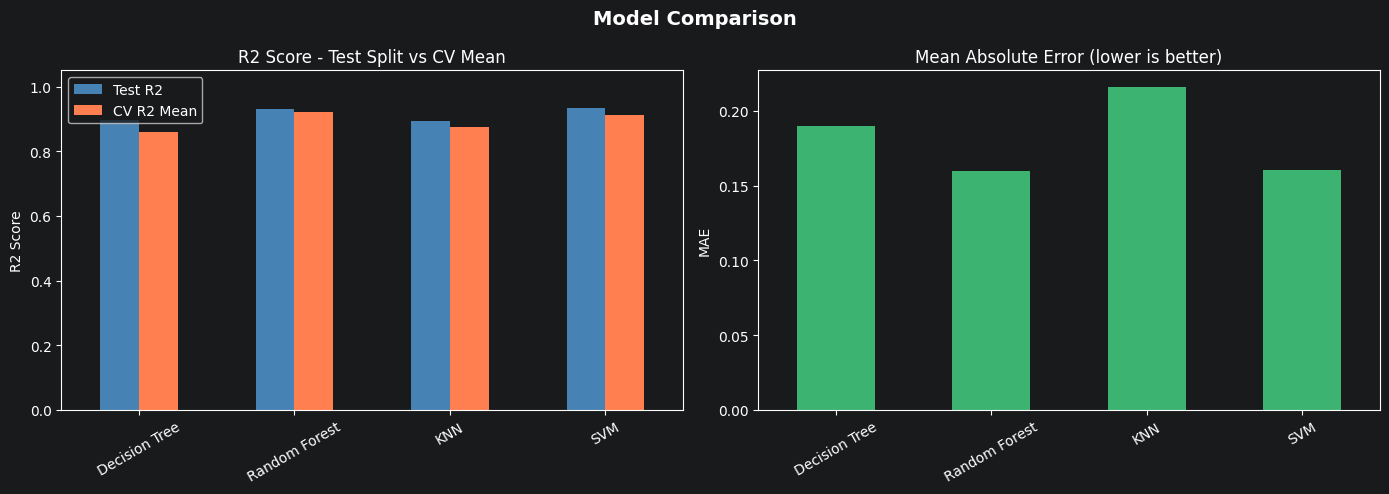

In [9]:
# 9 - Model Comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison', fontsize=14, fontweight='bold')

r2_data = results_df[['R2', 'CV R2 Mean']].astype(float)
r2_data.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('R2 Score - Test Split vs CV Mean')
axes[0].set_ylabel('R2 Score')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(['Test R2', 'CV R2 Mean'])
axes[0].set_ylim(min(0.0, float(r2_data.values.min()) - 0.05), 1.05)

results_df['MAE'].astype(float).plot(kind='bar', ax=axes[1], color='mediumseagreen')
axes[1].set_title('Mean Absolute Error (lower is better)')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

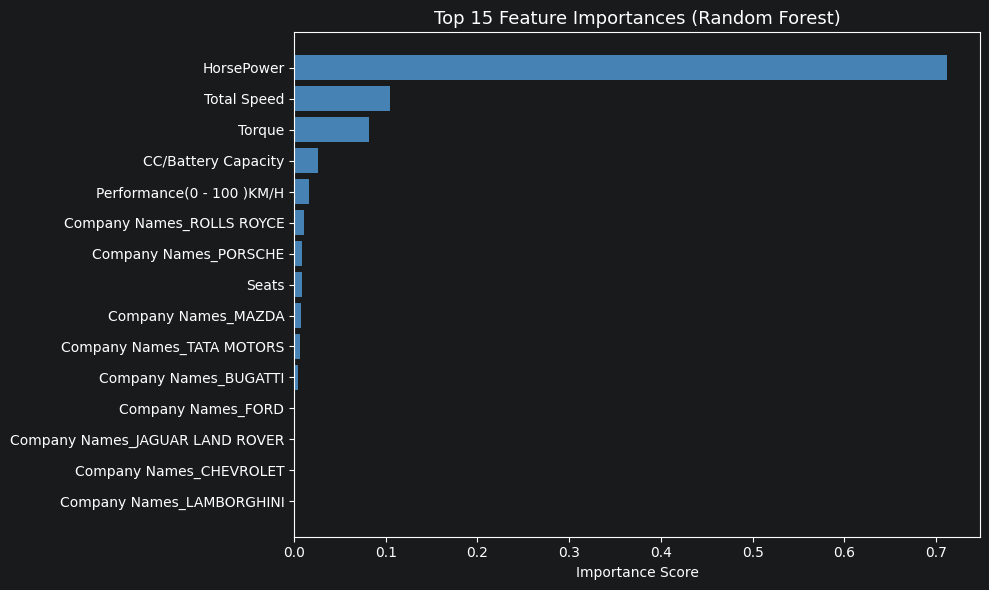

In [10]:
# 10 - Feature Importance (Random Forest)

rf_estimator = trained['Random Forest'].named_steps['model']

importance_df = (
    pd.DataFrame({'Feature': X.columns, 'Importance': rf_estimator.feature_importances_})
    .sort_values('Importance', ascending=True)
)

top_features = importance_df.tail(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'], color='steelblue')
plt.title('Top 15 Feature Importances (Random Forest)', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [11]:
# 11 - Car Recommendation System
# Content-based filtering: ranks cars by Value Score (HorsePower per dollar) — best value first.

def recommend(budget, seats=None, fuel_type=None, brand=None, top_n=5):
    """Returns top cars within budget filtered by seats, fuel type, and brand preference."""
    result = df_original[df_original['Cars Prices'] <= budget].copy()

    if seats     is not None: result = result[result['Seats'].astype(int) == int(seats)]
    if fuel_type is not None: result = result[result['Fuel Types'].str.upper() == fuel_type.strip().upper()]
    if brand     is not None: result = result[result['Company Names'].str.upper() == brand.strip().upper()]

    if result.empty:
        print('No cars found. Try relaxing the filters.')
        return pd.DataFrame()

    result = result[result['Cars Prices'] > 0].copy()

    # Value Score: higher HP per dollar = better value
    result['Value Score'] = result['HorsePower'] / result['Cars Prices']
    result = result.sort_values('Value Score', ascending=False)

    return result[['Company Names', 'Cars Names', 'Cars Prices',
                   'HorsePower', 'Seats', 'Fuel Types']].head(top_n).reset_index(drop=True)


print('Cars Under $50,000')
display(recommend(50000))

print('\n5-Seater Cars Under $70,000')
display(recommend(70000, seats=5))

print('\nElectric Cars Under $80,000')
display(recommend(80000, fuel_type='ELECTRIC'))

print('\nToyota Cars Under $40,000')
display(recommend(40000, brand='TOYOTA'))

Cars Under $50,000


,Company Names,Cars Names,Cars Prices,HorsePower,Seats,Fuel Types
0,TATA MOTORS,Indica V2 Xeta,5000.0,65.0,5.0,PETROL
1,TATA MOTORS,Indigo GLX,7200.0,85.0,5.0,PETROL
2,TATA MOTORS,Indica eV2,6200.0,70.0,5.0,DIESEL
3,TOYOTA,CAMRY,27000.0,301.0,5.0,PETROL/HYBRID
4,NISSAN,370Z,30000.0,332.0,2.0,PETROL



5-Seater Cars Under $70,000


,Company Names,Cars Names,Cars Prices,HorsePower,Seats,Fuel Types
0,TATA MOTORS,Indica V2 Xeta,5000.0,65.0,5.0,PETROL
1,TATA MOTORS,Indigo GLX,7200.0,85.0,5.0,PETROL
2,TATA MOTORS,Indica eV2,6200.0,70.0,5.0,DIESEL
3,TOYOTA,CAMRY,27000.0,301.0,5.0,PETROL/HYBRID
4,TATA MOTORS,Indigo eCS,6500.0,70.0,5.0,DIESEL



Electric Cars Under $80,000


,Company Names,Cars Names,Cars Prices,HorsePower,Seats,Fuel Types
0,TESLA,Cybertruck,69900.0,800.0,6.0,ELECTRIC
1,KIA,EV6 GT Performance,65000.0,577.0,5.0,ELECTRIC
2,TESLA,Model 3 Performance,53240.0,450.0,5.0,ELECTRIC
3,HYUNDAI,IONIQ 6,41450.0,320.0,5.0,ELECTRIC
4,CADILLAC,Lyriq EV Premium,64990.0,500.0,5.0,ELECTRIC



Toyota Cars Under $40,000


,Company Names,Cars Names,Cars Prices,HorsePower,Seats,Fuel Types
0,TOYOTA,CAMRY,27000.0,301.0,5.0,PETROL/HYBRID
1,TOYOTA,TUNDRA,39900.0,381.0,5.0,PETROL
2,TOYOTA,GR COROLLA,36995.0,300.0,5.0,PETROL
3,TOYOTA,HIGHLANDER,38400.0,295.0,7.0,PETROL/HYBRID
4,TOYOTA,TOYOTA GR86,30000.0,228.0,4.0,PETROL


## Project Summary

**Project:** CarAdvisor — Car Price Prediction & Recommendation System  
**Author:** Dhruvik Parmar

### What Was Built
CarAdvisor is an intelligent car recommendation system that helps buyers make informed decisions.
It uses machine learning to predict car prices and recommends the best value cars
based on user preferences including budget, seats, fuel type, and brand.

### Dataset
- Source: Cars Datasets 2025
- Features used: HorsePower, Total Speed, Engine CC, Seats, Company, Fuel Type

### Models Trained and Evaluated
| Model         | Technique                      |
|---------------|--------------------------------|
| Decision Tree | Simple rule-based splits       |
| Random Forest | Ensemble of 100 trees          |
| KNN           | Distance-based prediction      |
| SVM (RBF)     | Best performer - highest CV R2 |

### Key Results
- **Best Model:** SVM with RBF Kernel
- **Evaluation:** 5-Fold Cross-Validation with Pipeline (no data leakage)
- **Feature Engineering:** Log-Price transformation reduced price skewness

### Recommendation System
Content-based filtering using user preferences: budget, seat count, fuel type, and brand.  
Results ranked by Value Score (HorsePower per dollar) for best value recommendations.

### Conclusion
CarAdvisor demonstrates an end-to-end machine learning pipeline:  
data cleaning, EDA, feature engineering, model training, and a personalised recommendation system.